<a href="https://colab.research.google.com/github/sileysa/Semester_5/blob/main/JS05/JS05_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Persiapan Dataset

## Import library

In [1]:
# ============================================
# TUGAS LAB 2
# MULTINOMIAL NAIVE BAYES
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## Membaca dataset

In [2]:
# Membaca dataset
df = pd.read_csv(
    '/content/spam.csv',
    encoding='latin1'
)

# Melihat informasi awal
print("Ukuran dataset:", df.shape)

display(df.head())

Ukuran dataset: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Membersihkan dataset

In [3]:
# Mengambil hanya kolom label dan teks
data = df[['v1', 'v2']].copy()

# Mengubah nama kolom
data.columns = ['label', 'text']

# Mengubah label menjadi angka
# ham  = 0
# spam = 1
data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

# Menghapus data kosong
data = data.dropna()

print("Ukuran dataset setelah preprocessing:", data.shape)

display(data.head())

Ukuran dataset setelah preprocessing: (5572, 2)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Jumlah masing-masing kelas:")
print(data['label'].value_counts())

print("\nPersentase masing-masing kelas:")
print(data['label'].value_counts(normalize=True) * 100)

Jumlah masing-masing kelas:
label
0    4825
1     747
Name: count, dtype: int64

Persentase masing-masing kelas:
label
0    86.593683
1    13.406317
Name: proportion, dtype: float64


# 2. Membagi Dataset

In [5]:
X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing :", len(X_test))

Jumlah data training: 4457
Jumlah data testing : 1115


# 3. Model CountVectorizer + Multinomial Naive Bayes

In [6]:
# ============================================
# MODEL 1
# COUNT VECTORIZER + MULTINOMIAL NAIVE BAYES
# ============================================

model_count = Pipeline([
    (
        'vectorizer',
        CountVectorizer(stop_words='english')
    ),
    (
        'nb',
        MultinomialNB()
    )
])

# Training model
model_count.fit(X_train, y_train)

# Prediksi
y_pred_count = model_count.predict(X_test)

print("Model CountVectorizer berhasil dibuat.")

Model CountVectorizer berhasil dibuat.


# 4. Evaluasi Model CountVectorizer

## Accuracy

In [7]:
accuracy_count = accuracy_score(
    y_test,
    y_pred_count
)

print("Accuracy:", accuracy_count)
print("Accuracy (%):", accuracy_count * 100)

Accuracy: 0.9838565022421525
Accuracy (%): 98.38565022421525


## Precision, Recall, dan F1-Score

In [8]:
precision_count = precision_score(
    y_test,
    y_pred_count
)

recall_count = recall_score(
    y_test,
    y_pred_count
)

f1_count = f1_score(
    y_test,
    y_pred_count
)

print("Precision :", precision_count)
print("Recall    :", recall_count)
print("F1-Score  :", f1_count)

Precision : 0.958041958041958
Recall    : 0.9194630872483222
F1-Score  : 0.9383561643835616


## Classification Report

In [9]:
print(
    classification_report(
        y_test,
        y_pred_count,
        target_names=['ham', 'spam']
    )
)

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# 5. Confusion Matrix CountVectorizer

In [10]:
cm_count = confusion_matrix(
    y_test,
    y_pred_count
)

print("Confusion Matrix:")
print(cm_count)

Confusion Matrix:
[[960   6]
 [ 12 137]]


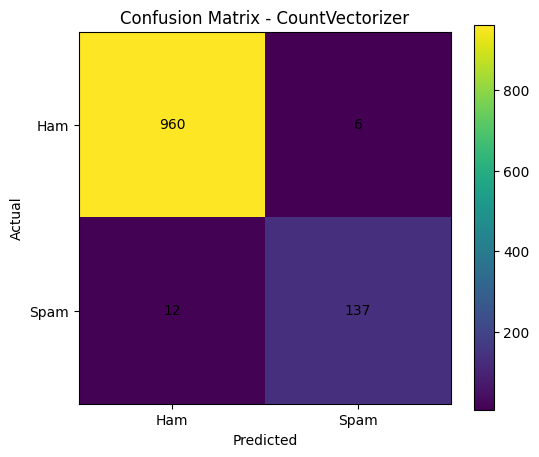

In [11]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_count)

plt.title('Confusion Matrix - CountVectorizer')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(
    [0, 1],
    ['Ham', 'Spam']
)

plt.yticks(
    [0, 1],
    ['Ham', 'Spam']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_count[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()

# 6. Model TF-IDF + Multinomial Naive Bayes

In [12]:
# ============================================
# MODEL 2
# TF-IDF + MULTINOMIAL NAIVE BAYES
# ============================================

model_tfidf = Pipeline([
    (
        'vectorizer',
        TfidfVectorizer(stop_words='english')
    ),
    (
        'nb',
        MultinomialNB()
    )
])

# Training
model_tfidf.fit(X_train, y_train)

# Prediksi
y_pred_tfidf = model_tfidf.predict(X_test)

print("Model TF-IDF berhasil dibuat.")

Model TF-IDF berhasil dibuat.


# 7. Evaluasi Model TF-IDF

## Accuracy

In [13]:
accuracy_tfidf = accuracy_score(
    y_test,
    y_pred_tfidf
)

print("Accuracy:", accuracy_tfidf)
print("Accuracy (%):", accuracy_tfidf * 100)

Accuracy: 0.968609865470852
Accuracy (%): 96.8609865470852


## Precision, Recall, F1-Score

In [14]:
precision_tfidf = precision_score(
    y_test,
    y_pred_tfidf
)

recall_tfidf = recall_score(
    y_test,
    y_pred_tfidf
)

f1_tfidf = f1_score(
    y_test,
    y_pred_tfidf
)

print("Precision :", precision_tfidf)
print("Recall    :", recall_tfidf)
print("F1-Score  :", f1_tfidf)

Precision : 1.0
Recall    : 0.7651006711409396
F1-Score  : 0.8669201520912547


## Classification Report

In [15]:
print(
    classification_report(
        y_test,
        y_pred_tfidf,
        target_names=['ham', 'spam']
    )
)

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



# 8. Confusion Matrix TF-IDF

In [16]:
cm_tfidf = confusion_matrix(
    y_test,
    y_pred_tfidf
)

print("Confusion Matrix:")
print(cm_tfidf)

Confusion Matrix:
[[966   0]
 [ 35 114]]


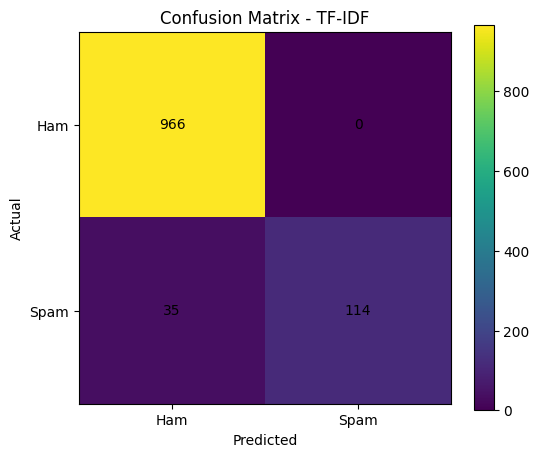

In [17]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_tfidf)

plt.title('Confusion Matrix - TF-IDF')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks(
    [0, 1],
    ['Ham', 'Spam']
)

plt.yticks(
    [0, 1],
    ['Ham', 'Spam']
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_tfidf[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()

# 9. Membandingkan Kedua Model

In [18]:
# ============================================
# PERBANDINGAN MODEL
# ============================================

hasil_perbandingan = pd.DataFrame({
    'Model': [
        'CountVectorizer',
        'TF-IDF'
    ],
    'Accuracy': [
        accuracy_count,
        accuracy_tfidf
    ],
    'Precision': [
        precision_count,
        precision_tfidf
    ],
    'Recall': [
        recall_count,
        recall_tfidf
    ],
    'F1-Score': [
        f1_count,
        f1_tfidf
    ]
})

display(hasil_perbandingan)

,Model,Accuracy,Precision,Recall,F1-Score
0,CountVectorizer,0.983857,0.958042,0.919463,0.938356
1,TF-IDF,0.968610,1.000000,0.765101,0.866920


# 10. Grafik Perbandingan

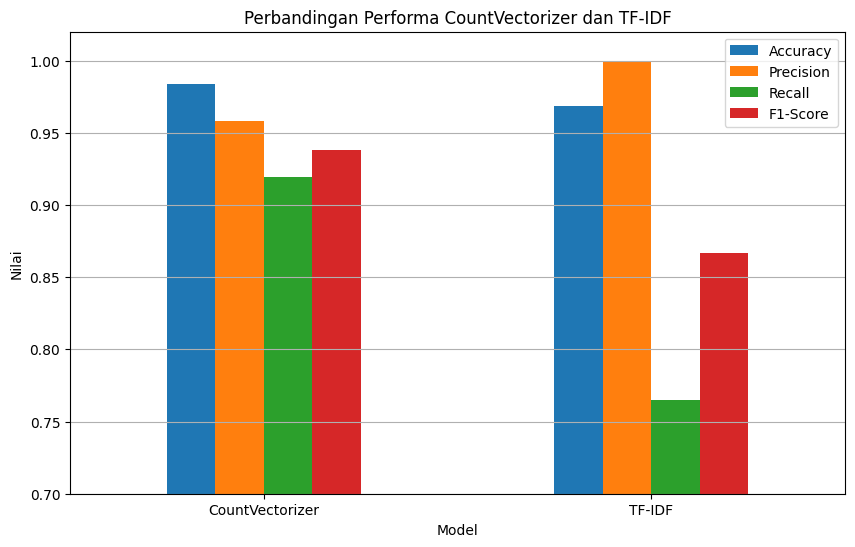

In [19]:
hasil_plot = hasil_perbandingan.set_index('Model')

hasil_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Perbandingan Performa CountVectorizer dan TF-IDF')
plt.ylabel('Nilai')
plt.xlabel('Model')
plt.ylim(0.7, 1.02)

plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

# 11. Mencari Model dengan Akurasi Tertinggi

In [20]:
model_terbaik = hasil_perbandingan.loc[
    hasil_perbandingan['Accuracy'].idxmax()
]

print("Model dengan accuracy tertinggi:")
print(model_terbaik)

Model dengan accuracy tertinggi:
Model        CountVectorizer
Accuracy            0.983857
Precision           0.958042
Recall              0.919463
F1-Score            0.938356
Name: 0, dtype: object
